# Drive



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import norm, pearsonr
import math
from scipy.stats import chi2, t as student_t


# Config

In [3]:
plt.rcParams.update({
    "figure.figsize":   (12, 5),
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "grid.linestyle":   ":",
    "font.size":        10,
})

DATE_FMT = mdates.DateFormatter("%b-%y")

In [4]:
SELECTED_TICKERS = [
    "DHR US Equity",
    "VRTX US Equity",
    "PANW US Equity",
    "ZBRA US Equity",
    "HIG US Equity",
    "NDAQ US Equity",
    "TDY US Equity",
]

# Palette colori
TICKER_COLORS = dict(zip(SELECTED_TICKERS,
    ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
     "#9467bd", "#8c564b", "#e377c2"]))

#Custom Function

In [5]:
def normalizza_ticker(t):
    """Uniforma spazi e maiuscole: 'PANW US EQUITY' -> 'PANW US Equity'."""
    t = " ".join(str(t).split())          # spazi singoli
    return t.replace(" US EQUITY", " US Equity").replace(" UN EQUITY", " UN Equity")

def carica_prezzi(filepath, sheet_name, tickers):
    """Legge il foglio prezzi e restituisce un DataFrame (date x ticker)."""
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)

    # riga 1 = nomi ticker, sulle colonne dispari (1, 3, 5, ...)
    riga_ticker = raw.iloc[1]
    colonna_di = {}
    for i in range(1, len(riga_ticker)):
        nome = riga_ticker[i]
        if pd.notna(nome):
            colonna_di[normalizza_ticker(nome)] = i

    # teniamo solo i ticker richiesti, nell'ordine di SELECTED_TICKERS
    date = pd.to_datetime(raw.iloc[2:, 0])
    dati = {}
    for t in tickers:
        col = colonna_di[t]
        dati[t] = pd.to_numeric(raw.iloc[2:, col], errors="coerce").values

    prezzi = pd.DataFrame(dati, index=date)
    prezzi.index.name = "Date"
    return prezzi.dropna(how="all")

def griglia_per_ticker(titolo):
    """Crea una griglia 4x2 di assi, uno per ticker, e nasconde gli slot in eccesso."""
    fig, axes = plt.subplots(4, 2, figsize=(15, 13))
    axes = axes.flatten()

    for ax in axes[len(SELECTED_TICKERS):]:
        ax.set_visible(False)

    fig.suptitle(titolo, fontsize=14, fontweight="bold", y=1.00)

    return fig, axes

In [6]:
def griglia_per_finestre(titolo, n_grafici, ncols=2):
    """Crea una griglia dinamica di assi in base al numero di finestre rolling."""

    nrows = math.ceil(n_grafici / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 4.2 * nrows)
    )

    axes = np.array(axes).flatten()

    for ax in axes[n_grafici:]:
        ax.set_visible(False)

    fig.suptitle(titolo, fontsize=14, fontweight="bold", y=1.00)

    return fig, axes

In [7]:
def pvalue_matrix(df_ret):
    """Matrice dei p-value del test di Pearson su ogni coppia di colonne."""
    cols = df_ret.columns
    pv = pd.DataFrame(np.nan, index=cols, columns=cols)

    for a in cols:
        for b in cols:
            if a == b:
                pv.loc[a, b] = 0.0
            else:
                pair = df_ret[[a, b]].dropna()
                pv.loc[a, b] = pearsonr(pair[a], pair[b])[1]

    return pv


def stelle(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def mean_off_diagonal_corr(corr_matrix):
    """Media delle correlazioni escludendo la diagonale."""
    mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
    return corr_matrix.values[mask].mean()



In [8]:
def var_gaussiano(rets, alpha, horizon_days):
    """
    VaR parametrico gaussiano.
    VaR espresso come perdita positiva.
    """
    mu = rets.mean() * horizon_days
    sigma = rets.std(ddof=1) * np.sqrt(horizon_days)

    z_alpha = norm.ppf(alpha)

    var = -(mu + sigma * z_alpha)

    return var


def var_storico(rets, alpha, horizon_days):
    """
    VaR storico.
    Per backtesting giornaliero usa horizon_days=1.
    """
    if horizon_days != 1:
        raise ValueError("Per semplicità, il VaR storico qui è implementato per horizon_days=1.")

    var = -rets.quantile(alpha)

    return var


def var_montecarlo(
    rets,
    alpha,
    n_sim,
    seed,
    horizon_days,
    kind
):
    """
    VaR Monte Carlo.

    kind:
    - 'normal'    : simulazione normale parametrica
    - 'student_t' : simulazione Student-t, più adatta se vuoi code pesanti
    - 'bootstrap' : campionamento empirico con reinserimento
    """

    rng = np.random.default_rng(seed)
    out = {}

    for ticker in rets.columns:

        x = rets[ticker].dropna().values

        if kind == "normal":

            mu = np.mean(x)
            sigma = np.std(x, ddof=1)

            sim = rng.normal(
                loc=mu,
                scale=sigma,
                size=(n_sim, horizon_days)
            ).sum(axis=1)

        elif kind == "student_t":

            df, loc, scale = student_t.fit(x)

            sim = student_t.rvs(
                df=df,
                loc=loc,
                scale=scale,
                size=(n_sim, horizon_days),
                random_state=rng
            ).sum(axis=1)

        elif kind == "bootstrap":

            sim = rng.choice(
                x,
                size=(n_sim, horizon_days),
                replace=True
            ).sum(axis=1)

        else:
            raise ValueError("kind deve essere 'normal', 'student_t' oppure 'bootstrap'.")

        out[ticker] = -np.quantile(sim, alpha)

    return pd.Series(out)

In [9]:
def kupiec_test(exception_series, alpha):
    """
    Test di Kupiec, copertura non condizionata.

    H0: la frequenza delle eccezioni è uguale ad alpha.
    """

    exc = np.asarray(exception_series).astype(int)

    n = len(exc)
    x = exc.sum()

    pi_hat = x / n

    eps = 1e-12

    def log_likelihood(p):
        p = np.clip(p, eps, 1 - eps)
        return x * np.log(p) + (n - x) * np.log(1 - p)

    ll_null = log_likelihood(alpha)
    ll_alt = log_likelihood(pi_hat)

    lr_uc = -2 * (ll_null - ll_alt)
    p_value = 1 - chi2.cdf(lr_uc, df=1)

    return {
        "N": n,
        "Exceptions": x,
        "Expected Exceptions": alpha * n,
        "Exception Rate": pi_hat,
        "LR Kupiec": lr_uc,
        "P-value Kupiec": p_value
    }


def christoffersen_independence_test(exception_series):
    """
    Test di indipendenza di Christoffersen.

    H0: le eccezioni sono indipendenti nel tempo.
    """

    exc = np.asarray(exception_series).astype(int)

    if len(exc) < 2:
        return {
            "LR Independence": np.nan,
            "P-value Independence": np.nan
        }

    prev = exc[:-1]
    curr = exc[1:]

    n00 = np.sum((prev == 0) & (curr == 0))
    n01 = np.sum((prev == 0) & (curr == 1))
    n10 = np.sum((prev == 1) & (curr == 0))
    n11 = np.sum((prev == 1) & (curr == 1))

    n0 = n00 + n01
    n1 = n10 + n11

    eps = 1e-12

    def bernoulli_ll(successes, total, p):
        if total == 0:
            return 0.0
        p = np.clip(p, eps, 1 - eps)
        return successes * np.log(p) + (total - successes) * np.log(1 - p)

    pi = (n01 + n11) / (n0 + n1)

    pi0 = n01 / n0 if n0 > 0 else 0
    pi1 = n11 / n1 if n1 > 0 else 0

    ll_null = bernoulli_ll(n01 + n11, n0 + n1, pi)
    ll_alt = bernoulli_ll(n01, n0, pi0) + bernoulli_ll(n11, n1, pi1)

    lr_ind = -2 * (ll_null - ll_alt)
    p_value = 1 - chi2.cdf(lr_ind, df=1)

    return {
        "LR Independence": lr_ind,
        "P-value Independence": p_value,
        "N00": n00,
        "N01": n01,
        "N10": n10,
        "N11": n11
    }


def conditional_coverage_test(lr_kupiec, lr_independence):
    """
    Test di copertura condizionata:
    Kupiec + Christoffersen independence.
    """

    lr_cc = lr_kupiec + lr_independence
    p_value = 1 - chi2.cdf(lr_cc, df=2)

    return lr_cc, p_value

In [10]:
def ewma_vol_windowed(returns, window, lambda_, scale=252):
    """
    Calcola volatilità EWMA giornaliera usando:
    - lambda fisso
    - finestra rolling come lookback massimo
    """

    if not 0 < lambda_ < 1:
        raise ValueError("EWMA_LAMBDA deve essere compreso tra 0 e 1")

    # Pesi esponenziali: più peso alle osservazioni recenti
    weights = lambda_ ** np.arange(window - 1, -1, -1)
    weights = weights / weights.sum()

    ewma_var = returns.pow(2).rolling(window).apply(
        lambda x: np.dot(weights, x),
        raw=True
    )

    ewma_vol = np.sqrt(ewma_var) * np.sqrt(scale)

    return ewma_vol



# Risk Managment

## PUNTO 1

Selezionare 7 Equity quotate in US, visualizzare con grafici opportuni evoluzione del prezzo (in $), calcolare i rendimenti di periodo

In [11]:
FILE_NAME    = "/content/drive/MyDrive/Master/Risk/Business_Case_Valore_Rischio_2026_Light.xlsx" #inserire la directory del file
SHEET_PRICES = "Prezzi_Equity" #inserire nome del foglio

In [12]:
prices = carica_prezzi(FILE_NAME, SHEET_PRICES, SELECTED_TICKERS)
prices = prices.reset_index()
prices = prices.dropna()

prices.head()

,Date,DHR US Equity,VRTX US Equity,PANW US Equity,ZBRA US Equity,HIG US Equity,NDAQ US Equity,TDY US Equity
0,2021-07-19,251.5132,199.24,64.907,506.91,61.38,59.0500,420.26
1,2021-07-20,251.3802,196.55,66.832,519.67,62.33,60.3000,436.47
2,2021-07-21,248.0119,196.27,65.303,533.77,62.61,62.0933,442.38
3,2021-07-22,256.1313,196.02,66.393,536.22,61.58,61.7800,442.01
4,2021-07-23,258.1788,200.50,66.937,548.61,61.40,62.5867,445.66


In [13]:
log_returns    = np.log(prices[SELECTED_TICKERS] / prices[SELECTED_TICKERS].shift(1)).dropna()
simple_returns = prices[SELECTED_TICKERS].pct_change().dropna()

In [14]:
print("TABELLA DI CONTROLLO DEL PORTAFOGLIO")
print(f"Periodo dati: {prices.iloc[0,0].date()} -> {prices.iloc[-1,0].date()} "
      f"({len(prices)} osservazioni con frequenza giornaliera)\n")

TABELLA DI CONTROLLO DEL PORTAFOGLIO
Periodo dati: 2021-07-19 -> 2025-11-17 (1131 osservazioni con frequenza giornaliera)



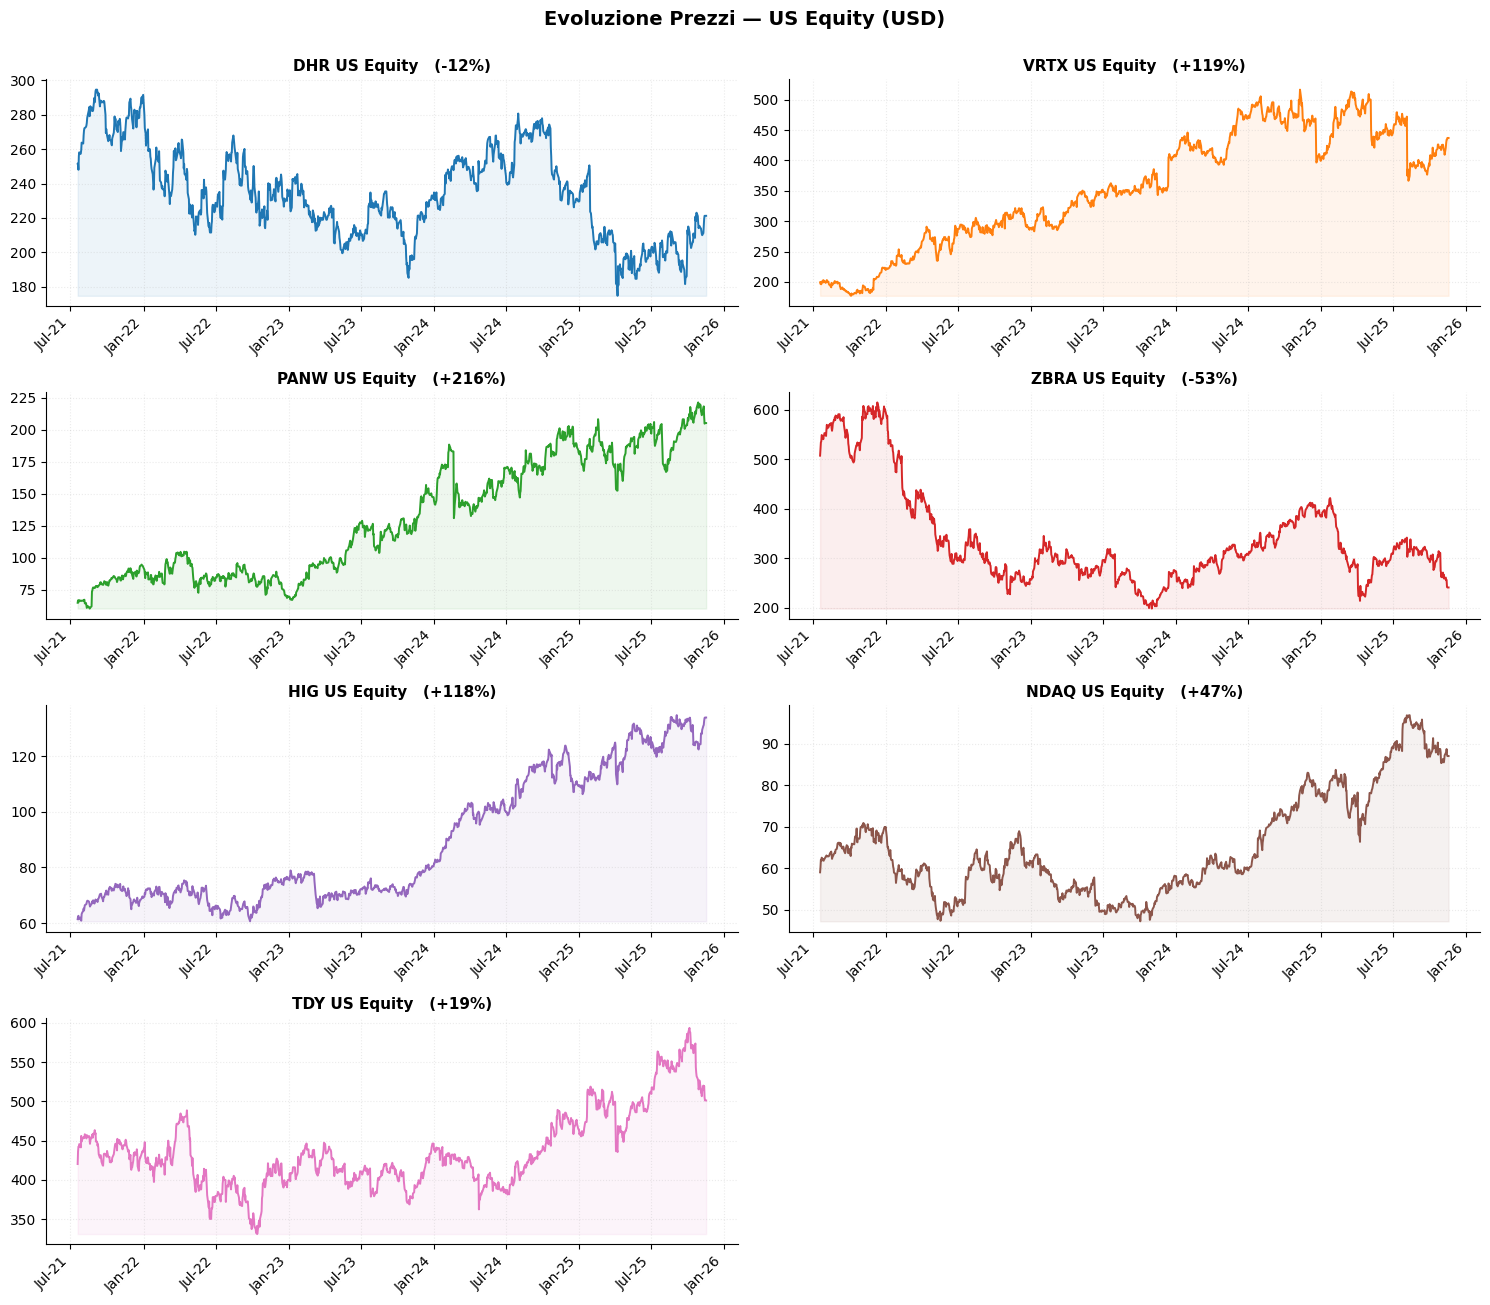

In [15]:
fig, axes = griglia_per_ticker("Evoluzione Prezzi — US Equity (USD)")

x = prices["Date"]

for ax, ticker in zip(axes, SELECTED_TICKERS):

    serie = prices[ticker]
    colore = TICKER_COLORS[ticker]

    # Linea + area sotto la curva
    ax.plot(x, serie, color=colore, linewidth=1.4)
    ax.fill_between(x, serie.min(), serie, color=colore, alpha=0.08)

    # Variazione percentuale di periodo
    var_pct = var_pct = (serie.iloc[-1] / serie.iloc[0] - 1) * 100
    ax.set_title(f"{ticker}   ({var_pct:+.0f}%)", fontsize=11)

    ax.xaxis.set_major_formatter(DATE_FMT)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

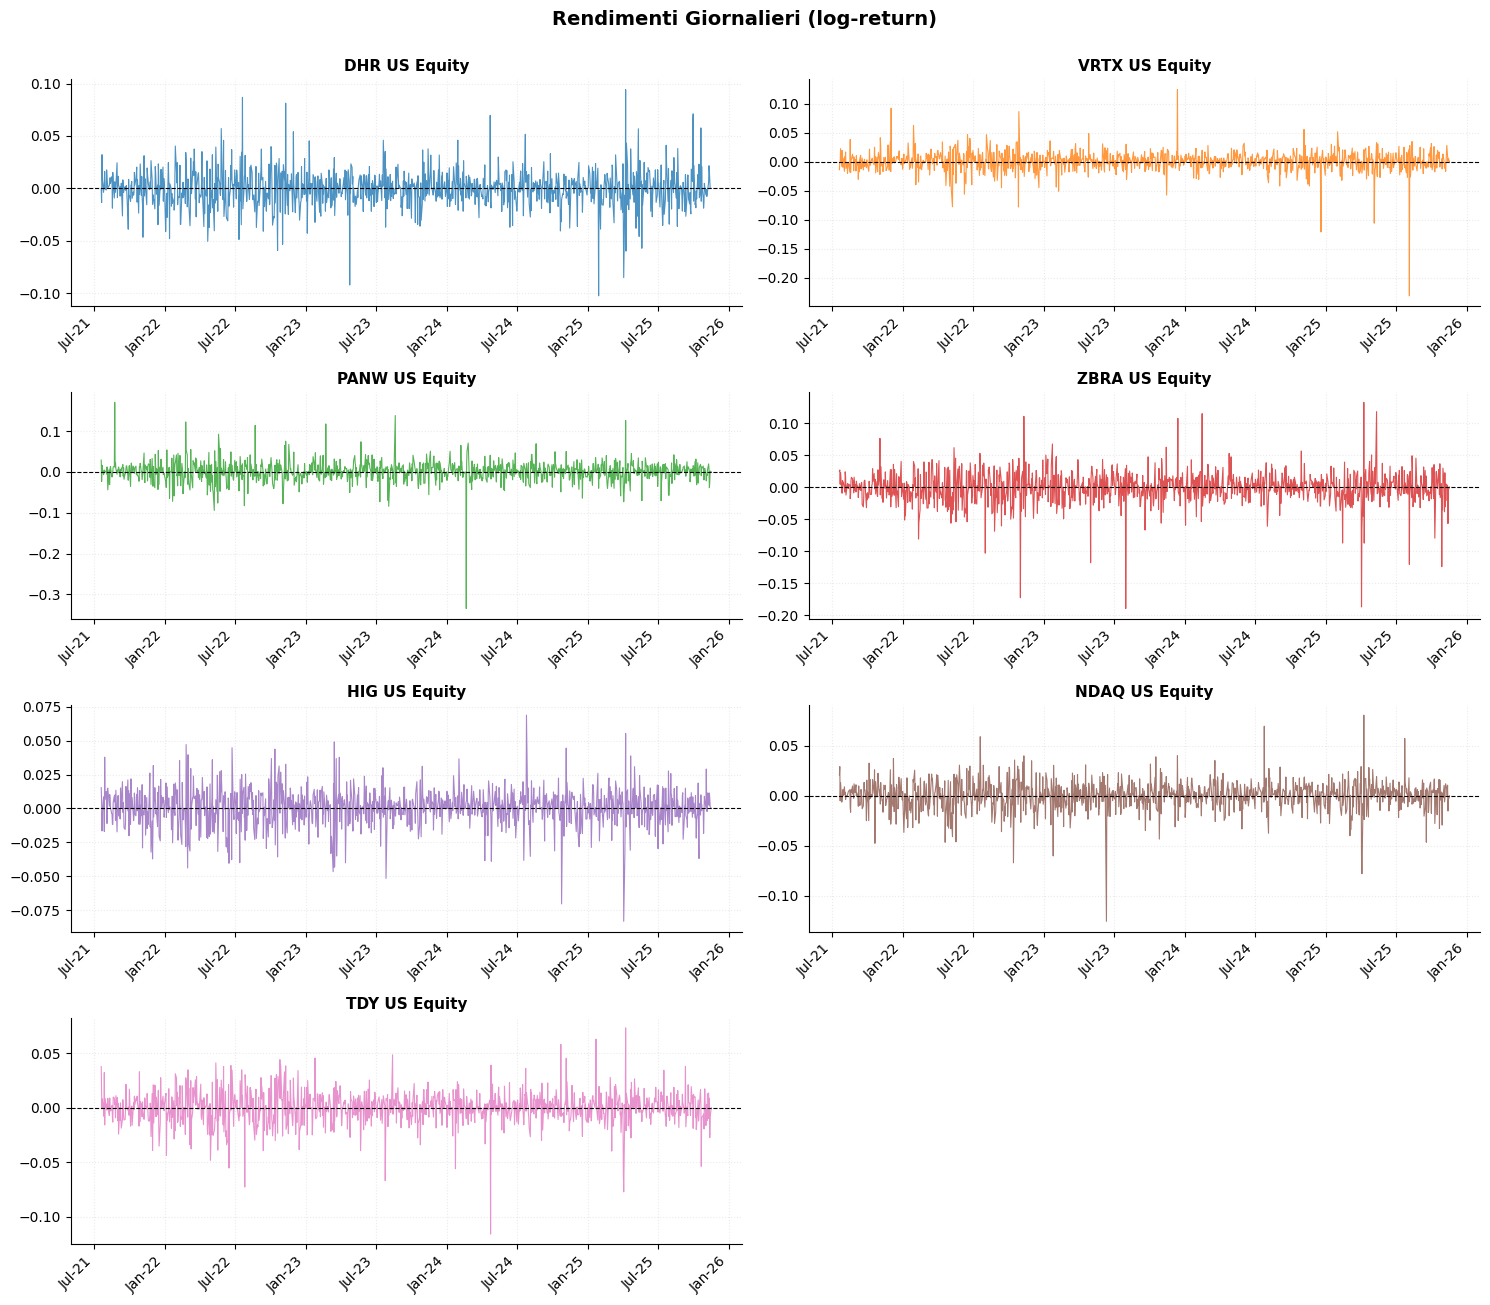

In [16]:
fig, axes = griglia_per_ticker("Rendimenti Giornalieri (log-return)")

x = prices["Date"][1:]


for ax, ticker in zip(axes, SELECTED_TICKERS):

    ax.plot(x, log_returns[ticker],

            color=TICKER_COLORS[ticker], linewidth=0.8, alpha=0.8)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(ticker, fontsize=11)
    ax.xaxis.set_major_formatter(DATE_FMT)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## PUNTO 2

 Per ogni  azione, determinare statistiche di sintesi, quali rendimento di periodo, volatilità (su varie "finestre" e unità di misura, per esempio 1D, 1M, 1Y), matrice di correlazione TRA equity (se possibile con test di significatività)

In [17]:
vol_1d = log_returns.std()

statistiche = pd.DataFrame({

    "Avg Log-return (%)":  (log_returns.mean() * 100).round(4),
    "Vol 1D (%)":        (vol_1d * 100).round(4),
    "Vol 1M (%)":        (vol_1d * np.sqrt(21) * 100).round(4),
    "Vol 1Y (%)":        (vol_1d * np.sqrt(252) * 100).round(4),

    "Q1 (%)":        (log_returns.quantile(0.25) * 100).round(4),
    "Mediana (%)":   (log_returns.quantile(0.50) * 100).round(4),
    "Q3 (%)":        (log_returns.quantile(0.75) * 100).round(4),

    "Min (%)":           (log_returns.min() * 100).round(4),
    "Max (%)":           (log_returns.max() * 100).round(4),

    "Skewness":          log_returns.apply(
                            lambda x: stats.skew(x.dropna(), bias=False)
                          ).round(4),

    "Excess Kurtosis":   log_returns.apply(
                            lambda x: stats.kurtosis(x.dropna(), fisher=True, bias=False)
                          ).round(4),
})


In [18]:
print("Statistiche descrittive — US Equity (log-return)\n")
print(statistiche.to_string())

Statistiche descrittive — US Equity (log-return)

                Avg Log-return (%)  Vol 1D (%)  Vol 1M (%)  Vol 1Y (%)  Q1 (%)  Mediana (%)  Q3 (%)  Min (%)  Max (%)  Skewness  Excess Kurtosis
DHR US Equity              -0.0114      1.7469      8.0052     27.7308 -0.9139       0.0000  0.8767 -10.2343   9.4196    0.0166           4.4522
VRTX US Equity              0.0695      1.7877      8.1924     28.3794 -0.7558       0.0896  0.9274 -23.0678  12.4281   -2.0716          30.6762
PANW US Equity              0.1019      2.6072     11.9476     41.3877 -1.0602       0.1004  1.3418 -33.4649  17.0591   -1.4010          27.7456
ZBRA US Equity             -0.0660      2.5305     11.5961     40.1702 -1.2954       0.0000  1.2361 -18.9609  13.2401   -0.9984           9.9403
HIG US Equity               0.0690      1.3772      6.3113     21.8630 -0.5917       0.1165  0.8679  -8.3336   6.8908   -0.3902           3.3100
NDAQ US Equity              0.0344      1.4638      6.7078     23.2365 -0.6353  

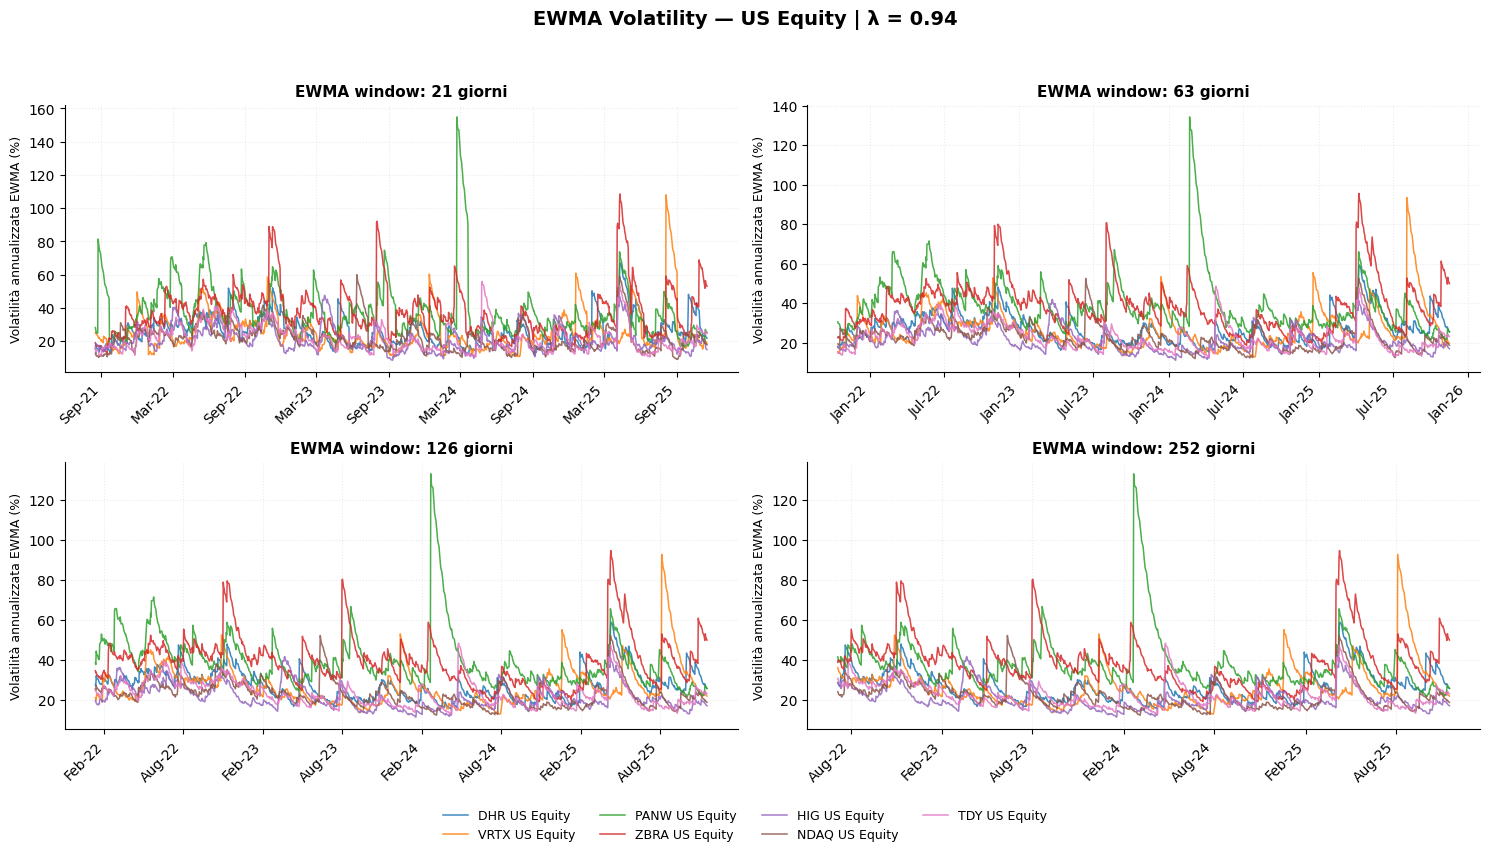

In [19]:
EWMA_WINDOWS = [21, 63, 126, 252]

EWMA_LAMBDA = 0.94
VOL_SCALE = 252
VOL_LABEL = "Volatilità annualizzata EWMA (%)"

x_returns = prices["Date"].iloc[-len(log_returns):].reset_index(drop=True)

returns = log_returns[SELECTED_TICKERS].copy().reset_index(drop=True)
returns.index = x_returns
returns.index.name = "Date"


fig, axes = griglia_per_finestre(
    f"EWMA Volatility — US Equity | λ = {EWMA_LAMBDA}",
    n_grafici=len(EWMA_WINDOWS),
    ncols=2
)

for ax, window in zip(axes, EWMA_WINDOWS):

    ewma_vol = ewma_vol_windowed(
        returns=returns,
        window=window,
        lambda_=EWMA_LAMBDA,
        scale=VOL_SCALE
    )*100

    for ticker in SELECTED_TICKERS:

        ax.plot(
            ewma_vol.index,
            ewma_vol[ticker],
            color=TICKER_COLORS[ticker],
            linewidth=1.1,
            alpha=0.85,
            label=ticker
        )

    ax.set_title(f"EWMA window: {window} giorni", fontsize=11)
    ax.set_ylabel(VOL_LABEL, fontsize=9)

    ax.xaxis.set_major_formatter(DATE_FMT)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha="right"
    )

    ax.tick_params(
        axis="x",
        which="both",
        labelbottom=True
    )

    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=min(len(SELECTED_TICKERS), 4),
    fontsize=9,
    frameon=False
)

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()

In [20]:
STRESS_START = "2022-02-01"
N_STRESS_OBS = 252

In [21]:
# Se log_returns non ha ancora indice Date, lo riallineo a prices["Date"]
if not isinstance(log_returns.index, pd.DatetimeIndex):
    x_returns = prices["Date"].iloc[-len(log_returns):].reset_index(drop=True)
    log_returns = log_returns[SELECTED_TICKERS].copy().reset_index(drop=True)
    log_returns.index = pd.to_datetime(x_returns)
    log_returns.index.name = "Date"
else:
    log_returns = log_returns[SELECTED_TICKERS].copy()

# --- Finestra stressed ---
log_ret_stress = log_returns.loc[STRESS_START:].iloc[:N_STRESS_OBS]

if len(log_ret_stress) < N_STRESS_OBS:
    raise ValueError(
        f"Finestra stressed: solo {len(log_ret_stress)} osservazioni, "
        f"ne servono {N_STRESS_OBS}."
    )

stress_start = log_ret_stress.index[0]
stress_end = log_ret_stress.index[-1]

# --- Tutto fuorché stress window ---
log_ret_no_stress = log_returns.drop(index=log_ret_stress.index)

print(
    f"Finestra stressed: {stress_start.date()} -> {stress_end.date()} "
    f"({len(log_ret_stress)} obs)"
)

print(
    f"Osservazioni full sample: {len(log_returns)} | "
    f"fuori stress: {len(log_ret_no_stress)}"
)


Finestra stressed: 2022-02-01 -> 2023-01-18 (252 obs)
Osservazioni full sample: 1130 | fuori stress: 878


In [22]:
# --- Matrici di correlazione ---
corr_full = log_returns.corr()
corr_stress = log_ret_stress.corr()
corr_no_stress = log_ret_no_stress.corr()

# --- P-value per tutte e tre le matrici ---
pval_full = pvalue_matrix(log_returns)
pval_stress = pvalue_matrix(log_ret_stress)
pval_no_stress = pvalue_matrix(log_ret_no_stress)

# --- Correlazioni medie ---
rho_full = mean_off_diagonal_corr(corr_full)
rho_stress = mean_off_diagonal_corr(corr_stress)
rho_no_stress = mean_off_diagonal_corr(corr_no_stress)

print(
    f"Correlazione media — storica: {rho_full:.3f} | "
    f"stress: {rho_stress:.3f} | "
    f"fuori stress: {rho_no_stress:.3f}"
)


Correlazione media — storica: 0.328 | stress: 0.482 | fuori stress: 0.263


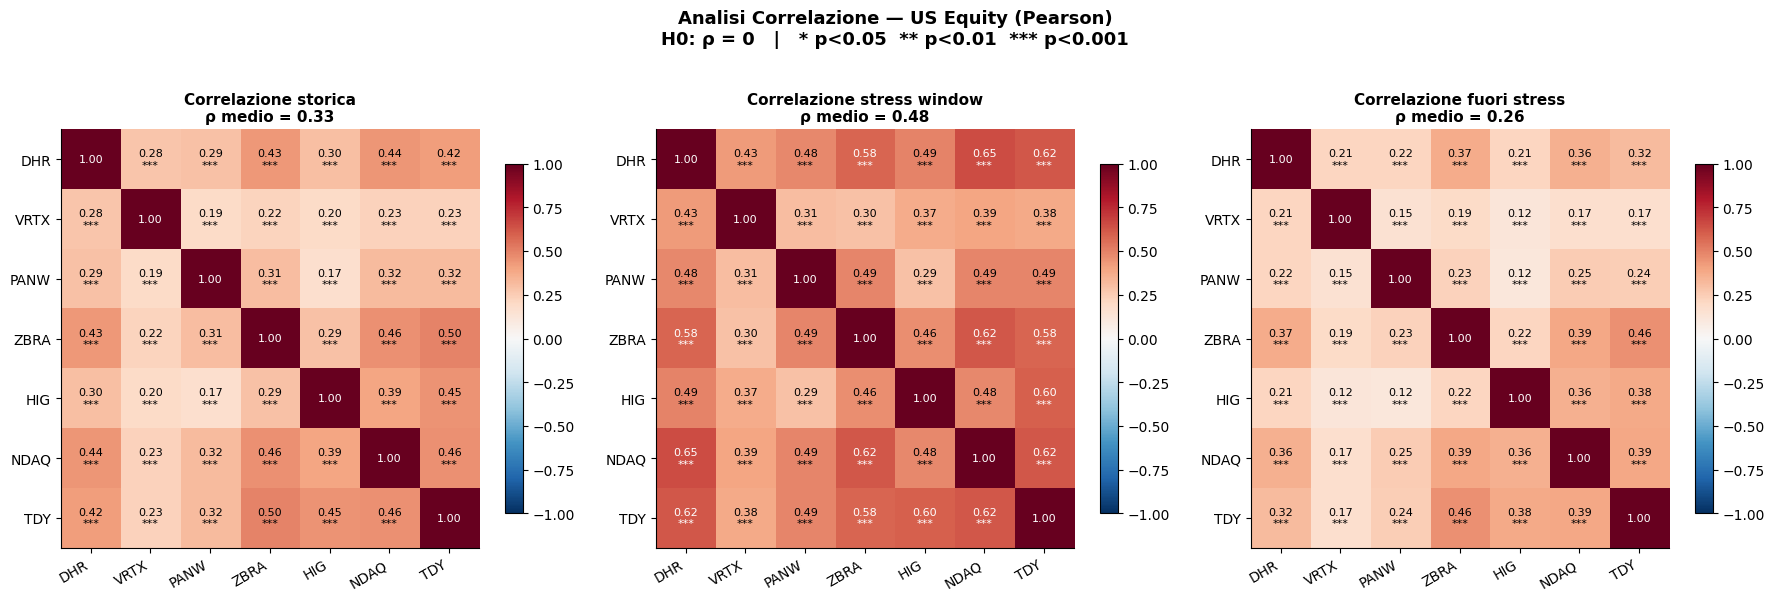


Durante la finestra di stress la correlazione media passa da 0.26 fuori stress a 0.48 in stress.


In [23]:
short = [t.split()[0] for t in SELECTED_TICKERS]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

pannelli = [
    (
        corr_full,
        pval_full,
        f"Correlazione storica\nρ medio = {rho_full:.2f}"
    ),
    (
        corr_stress,
        pval_stress,
        f"Correlazione stress window\nρ medio = {rho_stress:.2f}"
    ),
    (
        corr_no_stress,
        pval_no_stress,
        f"Correlazione fuori stress\nρ medio = {rho_no_stress:.2f}"
    ),
]

for ax, (M, pv, titolo) in zip(axes, pannelli):

    im = ax.imshow(M.values, cmap="RdBu_r", vmin=-1, vmax=1)

    ax.set_xticks(range(len(short)))
    ax.set_xticklabels(short, rotation=30, ha="right")

    ax.set_yticks(range(len(short)))
    ax.set_yticklabels(short)

    for i in range(len(short)):
        for j in range(len(short)):

            v = M.iloc[i, j]
            p = pv.iloc[i, j]

            if i == j:
                txt = f"{v:.2f}"
            else:
                txt = f"{v:.2f}\n{stelle(p)}"

            ax.text(
                j,
                i,
                txt,
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(v) > 0.5 else "black"
            )

    ax.set_title(titolo, fontsize=11)
    ax.grid(False)

    plt.colorbar(im, ax=ax, shrink=0.75)

fig.suptitle(
    "Analisi Correlazione — US Equity (Pearson)\n"
    "H0: ρ = 0   |   * p<0.05  ** p<0.01  *** p<0.001",
    fontsize=13,
    fontweight="bold",
    y=1.05
)

plt.tight_layout()
plt.show()

print(
    f"\nDurante la finestra di stress la correlazione media passa da "
    f"{rho_no_stress:.2f} fuori stress a {rho_stress:.2f} in stress."
)

## PUNTO 3
Per ogni azione, determinare VaR con modalità a scelta, parametrico-gaussiana e/o simulazione storica e/o Montecarlo

In [24]:
ALPHA = 0.01       # 0.05 = VaR 95%, 0.01 = VaR 99%
ESTIMATION_FRAC = 0.70 #fazione dei dai per la stima del var (1- ESTIMATION_FRAC per il backtesting)
N_SIM = 100_000 #numero di MC sim
MC_SEED = 42 #seed per montecarlo

HORIZON_DAYS = 1     # per backtesting giornaliero
MC_KIND = "student_t"  # "normal", "student_t", oppure "bootstrap" (WE SUGGEST TO USE SECOND AND THIRD OPTION)

SIGNIF_LEVEL = 0.05  # livello test statistici

In [25]:
if not isinstance(log_returns.index, pd.DatetimeIndex):

    x_returns = prices["Date"].iloc[-len(log_returns):].reset_index(drop=True)

    rets = log_returns[SELECTED_TICKERS].copy().reset_index(drop=True)
    rets.index = pd.to_datetime(x_returns)
    rets.index.name = "Date"
else:
    rets = log_returns[SELECTED_TICKERS].copy()

rets = rets.dropna()

n_obs = len(rets)
n_est = int(n_obs * ESTIMATION_FRAC)

rets_est = rets.iloc[:n_est]
rets_oos = rets.iloc[n_est:]

print(f"Osservazioni totali: {n_obs}")
print(f"Stima: {rets_est.index[0].date()} -> {rets_est.index[-1].date()} ({len(rets_est)} obs)")
print(f"Backtest OOS: {rets_oos.index[0].date()} -> {rets_oos.index[-1].date()} ({len(rets_oos)} obs)")
print(f"Livello VaR: {(1 - ALPHA) * 100:.1f}%")
print(f"Monte Carlo: {MC_KIND}")

Osservazioni totali: 1130
Stima: 2021-07-20 -> 2024-07-30 (791 obs)
Backtest OOS: 2024-07-31 -> 2025-11-17 (339 obs)
Livello VaR: 99.0%
Monte Carlo: student_t


In [27]:
var_gauss = var_gaussiano(rets_est, ALPHA, HORIZON_DAYS)
var_hist = var_storico(rets_est, ALPHA, HORIZON_DAYS)
var_mc = var_montecarlo(rets_est, ALPHA, N_SIM, MC_SEED, HORIZON_DAYS, MC_KIND)

confronto_var = pd.DataFrame({
    "Gaussiano (%)":   (var_gauss * 100).round(3),
    "Storico (%)":     (var_hist  * 100).round(3),
    "Monte Carlo (%)": (var_mc    * 100).round(3),
})

confronto_var.index = [t.split()[0] for t in SELECTED_TICKERS]

print(f"VaR singole equity {1 - ALPHA:.0%} {HORIZON_DAYS}D — dati di stima\n")
print(confronto_var.to_string())

VaR singole equity 99% 1D — dati di stima

      Gaussiano (%)  Storico (%)  Monte Carlo (%)
DHR           3.920        4.127            4.470
VRTX          3.632        4.354            4.196
PANW          6.353        6.975            7.103
ZBRA          5.850        5.954            6.268
HIG           3.166        3.911            3.622
NDAQ          3.456        3.705            3.863
TDY           3.525        3.933            4.063


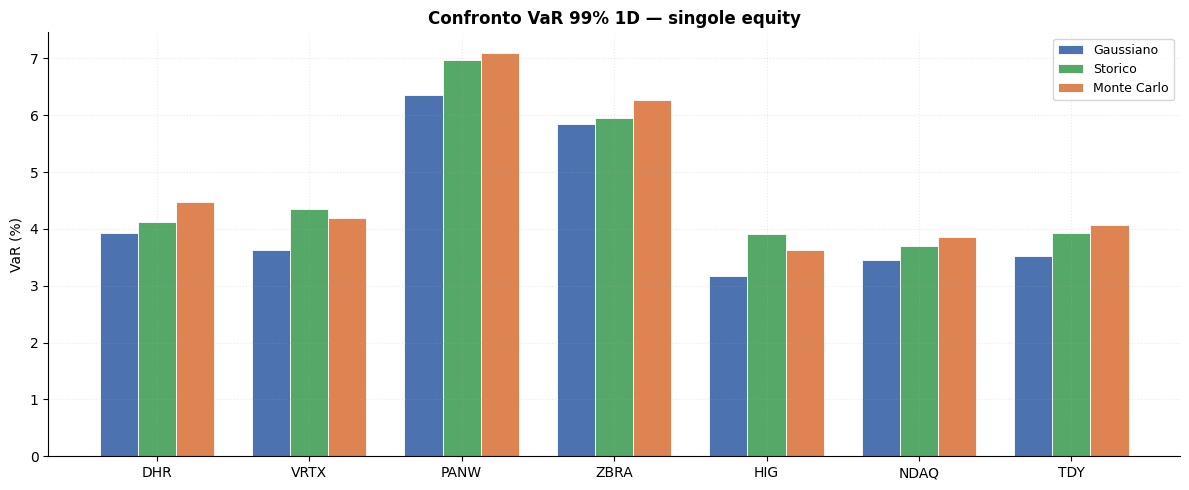

In [28]:
x = np.arange(len(confronto_var))
width = 0.25

metodi = [
    ("Gaussiano (%)", "#4c72b0"),
    ("Storico (%)", "#55a868"),
    ("Monte Carlo (%)", "#dd8452")
]

fig, ax = plt.subplots(figsize=(12, 5))

for i, (col, color) in enumerate(metodi):
    ax.bar(
        x + i * width,
        confronto_var[col],
        width,
        label=col.replace(" (%)", ""),
        color=color,
        edgecolor="white",
        linewidth=0.6
    )

ax.set_xticks(x + width)
ax.set_xticklabels(confronto_var.index)

ax.set_ylabel("VaR (%)")
ax.set_title(f"Confronto VaR {1 - ALPHA:.0%} {HORIZON_DAYS}D — singole equity")

ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
var_table = pd.DataFrame({
    "VaR Gaussiano": var_gauss,
    "VaR Storico": var_hist,
    f"VaR Monte Carlo ({MC_KIND})": var_mc
})

In [30]:
losses_oos = -rets_oos

exceptions = {}

for method in var_table.columns:
    exceptions[method] = losses_oos.gt(var_table[method], axis=1)

In [31]:
results = []

for method in var_table.columns:

    exc_method = exceptions[method]

    for ticker in SELECTED_TICKERS:

        exc = exc_method[ticker]

        kupiec = kupiec_test(exc, alpha=ALPHA)
        christ = christoffersen_independence_test(exc)

        lr_cc, p_cc = conditional_coverage_test(
            kupiec["LR Kupiec"],
            christ["LR Independence"]
        )

        results.append({
            "Metodo": method,
            "Ticker": ticker,
            "VaR": var_table.loc[ticker, method],
            "N Backtest": kupiec["N"],
            "Eccezioni": kupiec["Exceptions"],
            "Eccezioni Attese": kupiec["Expected Exceptions"],
            "Exception Rate": kupiec["Exception Rate"],
            "Kupiec p-value": kupiec["P-value Kupiec"],
            "Independence p-value": christ["P-value Independence"],
            "Conditional Coverage p-value": p_cc,
            "OK Kupiec": kupiec["P-value Kupiec"] > SIGNIF_LEVEL,
            "OK Independence": christ["P-value Independence"] > SIGNIF_LEVEL,
            "OK Conditional Coverage": p_cc > SIGNIF_LEVEL
        })

backtest_results = pd.DataFrame(results)

backtest_results = backtest_results.set_index(["Metodo", "Ticker"])

display(
    backtest_results.round({
        "VaR": 4,
        "Eccezioni Attese": 2,
        "Exception Rate": 4,
        "Kupiec p-value": 4,
        "Independence p-value": 4,
        "Conditional Coverage p-value": 4
    })
)

VaR  N Backtest  Eccezioni  \
Metodo                      Ticker                                          
VaR Gaussiano               DHR US Equity   0.0392         339          6   
                            VRTX US Equity  0.0363         339          7   
                            PANW US Equity  0.0635         339          4   
                            ZBRA US Equity  0.0585         339          8   
                            HIG US Equity   0.0317         339          5   
                            NDAQ US Equity  0.0346         339          5   
                            TDY US Equity   0.0352         339          4   
VaR Storico                 DHR US Equity   0.0413         339          5   
                            VRTX US Equity  0.0435         339          4   
                            PANW US Equity  0.0697         339          3   
                            ZBRA US Equity  0.0595         339          8   
                            HIG US Equity   0.0391         339          2   
                            NDAQ US Equity  0.0370         339          5   
                            TDY US Equity   0.0393         339          4   
VaR Monte Carlo (student_t) DHR US Equity   0.0447         339          5   
                            VRTX US Equity  0.0420         339          4   
                            PANW US Equity  0.0710         339          1   
                            ZBRA US Equity  0.0627         339          7   
                            HIG US Equity   0.0362         339          3   
                            NDAQ US Equity  0.0386         339          4   
                            TDY US Equity   0.0406         339          3   

                                            Eccezioni Attese  Exception Rate  \
Metodo                      Ticker                                             
VaR Gaussiano               DHR US Equity               3.39          0.0177   
                            VRTX US Equity              3.39          0.0206   
                            PANW US Equity              3.39          0.0118   
                            ZBRA US Equity              3.39          0.0236   
                            HIG US Equity               3.39          0.0147   
                            NDAQ US Equity              3.39          0.0147   
                            TDY US Equity               3.39          0.0118   
VaR Storico                 DHR US Equity               3.39          0.0147   
                            VRTX US Equity              3.39          0.0118   
                            PANW US Equity              3.39          0.0088   
                            ZBRA US Equity              3.39          0.0236   
                            HIG US Equity               3.39          0.0059   
                            NDAQ US Equity              3.39          0.0147   
                            TDY US Equity               3.39          0.0118   
VaR Monte Carlo (student_t) DHR US Equity               3.39          0.0147   
                            VRTX US Equity              3.39          0.0118   
                            PANW US Equity              3.39          0.0029   
                            ZBRA US Equity              3.39          0.0206   
                            HIG US Equity               3.39          0.0088   
                            NDAQ US Equity              3.39          0.0118   
                            TDY US Equity               3.39          0.0088   

                                            Kupiec p-value  \
Metodo                      Ticker                           
VaR Gaussiano               DHR US Equity           0.1988   
                            VRTX US Equity          0.0848   
                            PANW US Equity          0.7461   
                            ZBRA US Equity          0.0323   
                            HIG US Equity           0.4117   


## PUNTO 4
 E' dato il seguente Portafoglio equity, con i seguenti pesi. Considerare la liquidità un asset con ZERO volatilità e zero correlazione con gli altri componenti

In [32]:
INITIAL_CAPITAL = 100_000     # in dollari
TRADING_DAYS = 252

EQUITY_WEIGHTS = {
    "DHR US Equity":  0.1,
    "VRTX US Equity": 0.2,
    "PANW US Equity": 0.1,
    "ZBRA US Equity": 0.1,
    "HIG US Equity":  0.1,
    "NDAQ US Equity": 0.1,
    "TDY US Equity":  0.2,
}

CASH_WEIGHT     = 0.10

weights       = pd.Series(EQUITY_WEIGHTS).reindex(SELECTED_TICKERS)
market_values = INITIAL_CAPITAL * weights
cash_value    = INITIAL_CAPITAL * CASH_WEIGHT

print(f"\nEquity investita: ${market_values.sum():,.0f} "
      f"({weights.sum():.0%}) | Liquidità: ${cash_value:,.0f} "
      f"({CASH_WEIGHT:.0%}) | Totale: ${INITIAL_CAPITAL:,}")


Equity investita: $90,000 (90%) | Liquidità: $10,000 (10%) | Totale: $100,000


### PUNTO 4A
Su 3 anni di storia recente, visualizzare (a pesi constanti), l'evoluzione di valore di un investimento fatto 3 anni prima di 100.000 $ in tale portafoglio

In [33]:
PORTFOLIO_YEARS = 3
n_days_3y = PORTFOLIO_YEARS * TRADING_DAYS

prices_idx = prices.copy()

if "Date" in prices_idx.columns:
    prices_idx = prices_idx.set_index("Date")

prices_idx = prices_idx[SELECTED_TICKERS].dropna()

prices_3y = prices_idx.iloc[-(n_days_3y + 1):]

simple_3y = prices_3y.pct_change().dropna()

ret_port = simple_3y.mul(weights, axis=1).sum(axis=1)

portfolio_value = INITIAL_CAPITAL * (1 + ret_port).cumprod()

portfolio_value = pd.concat([
    pd.Series([INITIAL_CAPITAL], index=[prices_3y.index[0]]),
    portfolio_value
])

valore_finale = portfolio_value.iloc[-1]
rendimento_tot = (valore_finale / INITIAL_CAPITAL - 1) * 100

print(f"Finestra portafoglio: {portfolio_value.index[0].date()} -> "
      f"{portfolio_value.index[-1].date()} ({len(ret_port)} rendimenti)")

print(f"Pesi equity: {weights.sum():.0%} | Liquidità: {CASH_WEIGHT:.0%} "
      f"(rendimento e volatilità nulli)")

print(f"Capitale iniziale: ${INITIAL_CAPITAL:,.0f}")
print(f"Valore finale:     ${valore_finale:,.2f}")
print(f"Rendimento totale: {rendimento_tot:.2f}%")

Finestra portafoglio: 2022-12-23 -> 2025-11-17 (756 rendimenti)
Pesi equity: 90% | Liquidità: 10% (rendimento e volatilità nulli)
Capitale iniziale: $100,000
Valore finale:     $148,559.34
Rendimento totale: 48.56%


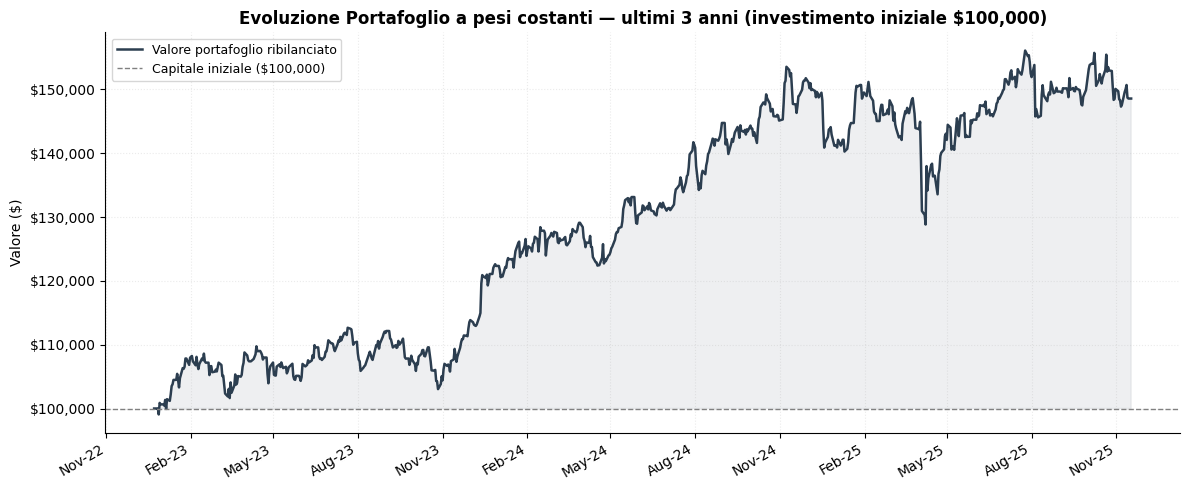

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    portfolio_value.index,
    portfolio_value,
    color="#2c3e50",
    linewidth=1.8,
    label="Valore portafoglio ribilanciato"
)

ax.fill_between(
    portfolio_value.index,
    INITIAL_CAPITAL,
    portfolio_value,
    where=portfolio_value >= INITIAL_CAPITAL,
    color="#2c3e50",
    alpha=0.08
)

ax.axhline(
    INITIAL_CAPITAL,
    color="grey",
    linewidth=1,
    linestyle="--",
    label=f"Capitale iniziale (${INITIAL_CAPITAL:,.0f})"
)

ax.set_title(
    f"Evoluzione Portafoglio a pesi costanti — ultimi {PORTFOLIO_YEARS} anni "
    f"(investimento iniziale ${INITIAL_CAPITAL:,.0f})"
)

ax.set_ylabel("Valore ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.xaxis.set_major_formatter(DATE_FMT)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

### PUNTO 4B
 visualizzare il rendimento giorno per giorno di tale portafoglio, la sua volatilità

In [35]:
window = 21

vol_port_1d = ret_port.std()
vol_port_1m = vol_port_1d * np.sqrt(21)
vol_port_1y = vol_port_1d * np.sqrt(252)

vol_ewma_ann = ewma_vol_windowed(
    returns=ret_port,
    window=window,
    lambda_=EWMA_LAMBDA,
    scale=252
)

print("Statistiche del portafoglio ribilanciato:")
print(f"  Rendimento medio giornaliero: {ret_port.mean()*100:.4f}%")
print(f"  Volatilità giornaliera:       {vol_port_1d*100:.2f}%")
print(f"  Volatilità mensile:           {vol_port_1m*100:.2f}%")
print(f"  Volatilità annualizzata:      {vol_port_1y*100:.2f}%")
print(f"  Volatilità EWMA media ann.:   {vol_ewma_ann.mean()*100:.2f}%")

Statistiche del portafoglio ribilanciato:
  Rendimento medio giornaliero: 0.0568%
  Volatilità giornaliera:       0.94%
  Volatilità mensile:           4.33%
  Volatilità annualizzata:      15.00%
  Volatilità EWMA media ann.:   14.05%


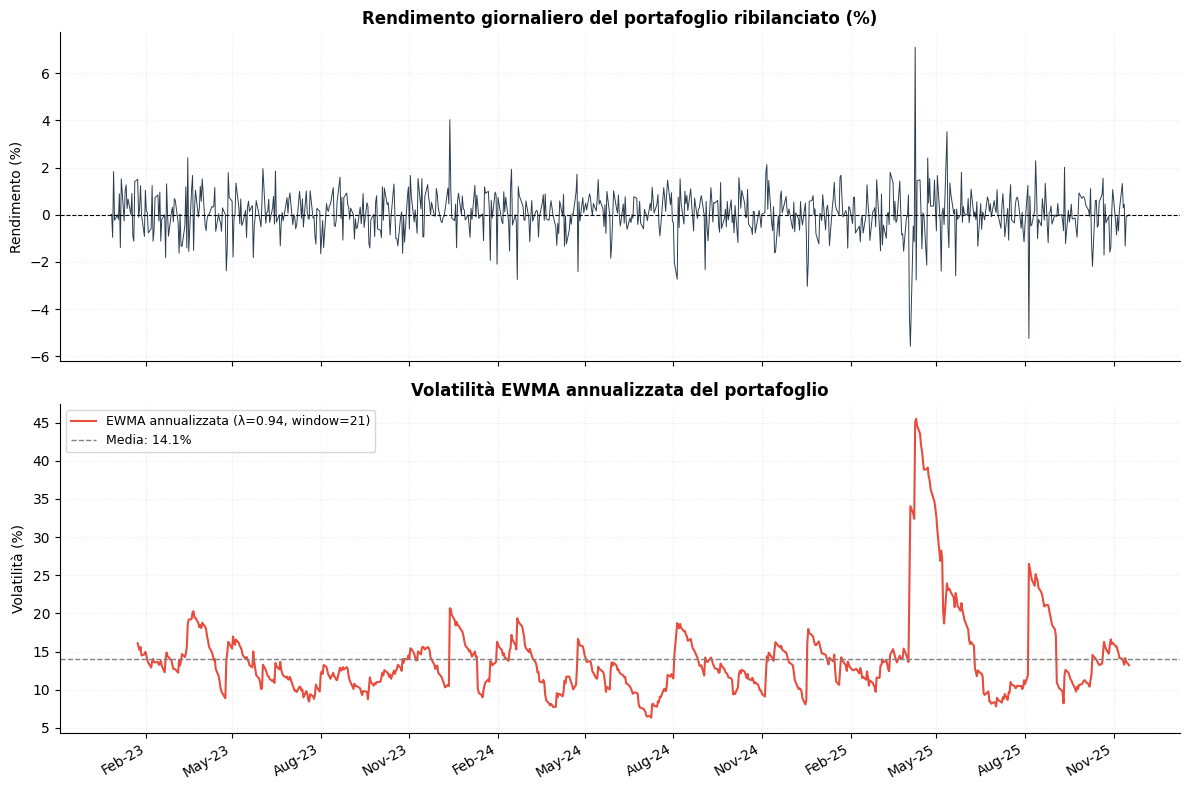

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Grafico rendimenti giornalieri
axes[0].plot(
    ret_port.index,
    ret_port * 100,
    color="#2c3e50",
    linewidth=0.7
)

axes[0].axhline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

axes[0].set_title("Rendimento giornaliero del portafoglio ribilanciato (%)")
axes[0].set_ylabel("Rendimento (%)")
axes[0].grid(alpha=0.25)

# Grafico volatilità EWMA annualizzata
axes[1].plot(
    vol_ewma_ann.index,
    vol_ewma_ann * 100,
    color="#e74c3c",
    linewidth=1.5,
    label=f"EWMA annualizzata (λ={EWMA_LAMBDA}, window={window})"
)

axes[1].axhline(
    vol_ewma_ann.mean() * 100,
    color="grey",
    linewidth=1,
    linestyle="--",
    label=f"Media: {vol_ewma_ann.mean()*100:.1f}%"
)

axes[1].set_title("Volatilità EWMA annualizzata del portafoglio")
axes[1].set_ylabel("Volatilità (%)")
axes[1].xaxis.set_major_formatter(DATE_FMT)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.setp(
    axes[1].xaxis.get_majorticklabels(),
    rotation=30,
    ha="right"
)

axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

### PUNTO 4C

con metodo a piacere, gaussiano (matrice di varianza-covarianza), o portfolio-normal (gaussiano su serie sintetica), o historical simulation, determinare il VaR del portafoglio in questione per investitore in $

In [37]:
ret_port_4c = ret_port.dropna()

var_hist_pct = -ret_port_4c.quantile(ALPHA)
var_hist_usd = INITIAL_CAPITAL * var_hist_pct

print(f"VaR storico portafoglio {(1 - ALPHA):.0%} {HORIZON_DAYS}D")
print(f"Capitale investito: ${INITIAL_CAPITAL:,.0f}")
print(f"VaR (%):            {var_hist_pct * 100:.2f}%")
print(f"VaR ($):            ${var_hist_usd:,.0f}")

VaR storico portafoglio 99% 1D
Capitale investito: $100,000
VaR (%):            2.49%
VaR ($):            $2,486


In [38]:
var_norm_pct = var_gaussiano(
    ret_port_4c,
    alpha=ALPHA,
    horizon_days=HORIZON_DAYS
)

var_norm_usd = INITIAL_CAPITAL * var_norm_pct

In [39]:
risultati_4c = pd.DataFrame({
    "VaR (%)": [
        var_hist_pct * 100,
        var_norm_pct * 100
    ],
    "VaR ($)": [
        var_hist_usd,
        var_norm_usd
    ]
}, index=[
    "Historical Simulation",
    "Portfolio-Normal"
])

risultati_4c["VaR (%)"] = risultati_4c["VaR (%)"].round(2)
risultati_4c["VaR ($)"] = risultati_4c["VaR ($)"].round(0)

print(f"VaR portafoglio {(1 - ALPHA):.0%} {HORIZON_DAYS}D "
      f"(capitale ${INITIAL_CAPITAL:,.0f})\n")

display(risultati_4c)

VaR portafoglio 99% 1D (capitale $100,000)



,VaR (%),VaR ($)
Historical Simulation,2.49,2486.0
Portfolio-Normal,2.14,2141.0


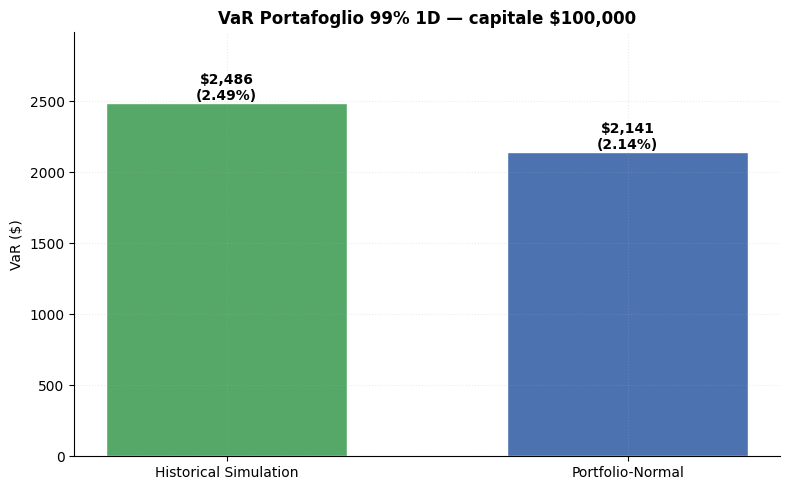

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    risultati_4c.index,
    risultati_4c["VaR ($)"],
    color=["#55a868", "#4c72b0"],
    edgecolor="white",
    width=0.6
)

for bar, (_, row) in zip(bars, risultati_4c.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${row['VaR ($)']:,.0f}\n({row['VaR (%)']:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel("VaR ($)")
ax.set_title(
    f"VaR Portafoglio {(1 - ALPHA):.0%} {HORIZON_DAYS}D — capitale ${INITIAL_CAPITAL:,.0f}"
)

ax.set_ylim(0, risultati_4c["VaR ($)"].max() * 1.20)

plt.tight_layout()
plt.show()

### PUNTO 4D
in base alla matrice di correlazione tra i componenti, giudicare se il portafoglio appare bene diversificato

In [41]:
equity_returns_4d = simple_3y[SELECTED_TICKERS].dropna()

weights_4d = weights.reindex(equity_returns_4d.columns).fillna(0)

if not np.isclose(weights_4d.sum() + CASH_WEIGHT, 1.0):
    raise ValueError("La somma dei pesi equity + cash deve essere pari a 100%.")

corr_4d = equity_returns_4d.corr()

display(corr_4d.round(3))

,DHR US Equity,VRTX US Equity,PANW US Equity,ZBRA US Equity,HIG US Equity,NDAQ US Equity,TDY US Equity
DHR US Equity,1.000,0.236,0.204,0.380,0.248,0.354,0.348
VRTX US Equity,0.236,1.000,0.179,0.191,0.138,0.187,0.170
PANW US Equity,0.204,0.179,1.000,0.231,0.127,0.242,0.247
ZBRA US Equity,0.380,0.191,0.231,1.000,0.222,0.376,0.462
HIG US Equity,0.248,0.138,0.127,0.222,1.000,0.369,0.387
NDAQ US Equity,0.354,0.187,0.242,0.376,0.369,1.000,0.394
TDY US Equity,0.348,0.170,0.247,0.462,0.387,0.394,1.000


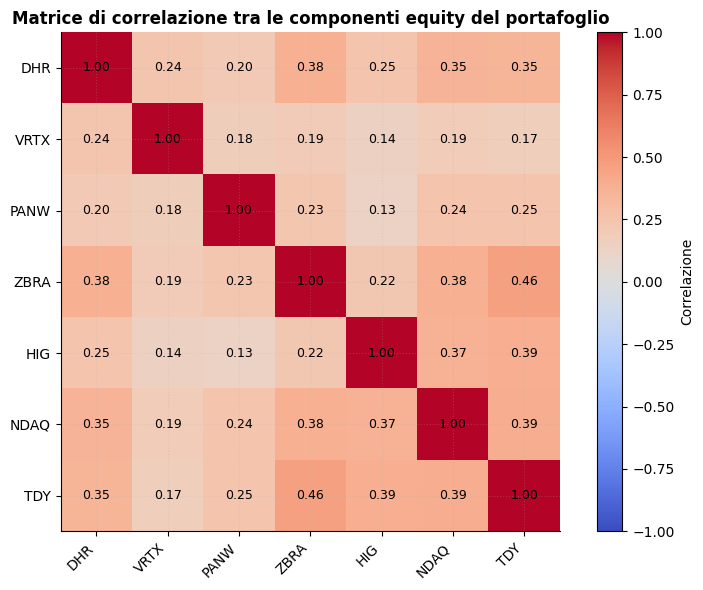

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_4d, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(np.arange(len(corr_4d.columns)))
ax.set_yticks(np.arange(len(corr_4d.index)))

labels = [t.replace(" US Equity", "") for t in corr_4d.columns]

ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(len(corr_4d.index)):
    for j in range(len(corr_4d.columns)):
        ax.text(
            j, i,
            f"{corr_4d.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

fig.colorbar(im, ax=ax, label="Correlazione")
ax.set_title("Matrice di correlazione tra le componenti equity del portafoglio")

plt.tight_layout()
plt.show()

In [43]:
mask_no_diag = ~np.eye(corr_4d.shape[0], dtype=bool)
corr_values = corr_4d.where(mask_no_diag).stack()

rho_mean = corr_values.mean()
rho_min = corr_values.min()
rho_max = corr_values.max()

w = weights_4d.values
rho = corr_4d.values

pair_weights = np.outer(w, w)
upper_mask = np.triu(np.ones_like(rho, dtype=bool), k=1)

rho_weighted = (
    pair_weights[upper_mask] * rho[upper_mask]
).sum() / pair_weights[upper_mask].sum()

summary_corr_4d = pd.DataFrame({
    "Valore": [
        rho_mean,
        rho_weighted,
        rho_min,
        rho_max
    ]
}, index=[
    "Correlazione media semplice",
    "Correlazione media pesata",
    "Correlazione minima",
    "Correlazione massima"
])

display(summary_corr_4d.round(3))

,Valore
Correlazione media semplice,0.271
Correlazione media pesata,0.264
Correlazione minima,0.127
Correlazione massima,0.462


In [44]:
vol_eq_1d = equity_returns_4d.std()

weighted_vol = weights_4d * vol_eq_1d

port_vol_div_1d = np.sqrt(
    weighted_vol.values @ corr_4d.values @ weighted_vol.values
)

port_vol_undiv_1d = weighted_vol.sum()

div_benefit_vol = 1 - port_vol_div_1d / port_vol_undiv_1d

ret_port_4d = ret_port.reindex(equity_returns_4d.index).dropna()
vol_port_direct_1d = ret_port_4d.std()

print("Controllo coerenza volatilità portafoglio:")
print(f"  Vol da matrice var-cov:   {port_vol_div_1d * 100:.4f}%")
print(f"  Vol diretta da ret_port:  {vol_port_direct_1d * 100:.4f}%")

Controllo coerenza volatilità portafoglio:
  Vol da matrice var-cov:   0.9448%
  Vol diretta da ret_port:  0.9448%


In [45]:
z = norm.ppf(1 - ALPHA)

var_div_usd = (
    INITIAL_CAPITAL
    * z
    * port_vol_div_1d
    * np.sqrt(HORIZON_DAYS)
)

var_undiv_usd = (
    INITIAL_CAPITAL
    * z
    * port_vol_undiv_1d
    * np.sqrt(HORIZON_DAYS)
)

div_benefit_var = 1 - var_div_usd / var_undiv_usd

summary_div_4d = pd.DataFrame({
    "Volatilità 1D (%)": [
        port_vol_div_1d * 100,
        port_vol_undiv_1d * 100
    ],
    f"VaR {(1 - ALPHA):.0%} {HORIZON_DAYS}D ($)": [
        var_div_usd,
        var_undiv_usd
    ]
}, index=[
    "Portafoglio diversificato",
    "Portafoglio non diversificato"
])

display(summary_div_4d.round(2))

print(f"Beneficio di diversificazione sulla volatilità: {div_benefit_vol * 100:.2f}%")
print(f"Beneficio di diversificazione sul VaR:          {div_benefit_var * 100:.2f}%")

,Volatilità 1D (%),VaR 99% 1D ($)
Portafoglio diversificato,0.94,2197.97
Portafoglio non diversificato,1.54,3587.92


Beneficio di diversificazione sulla volatilità: 38.74%
Beneficio di diversificazione sul VaR:          38.74%


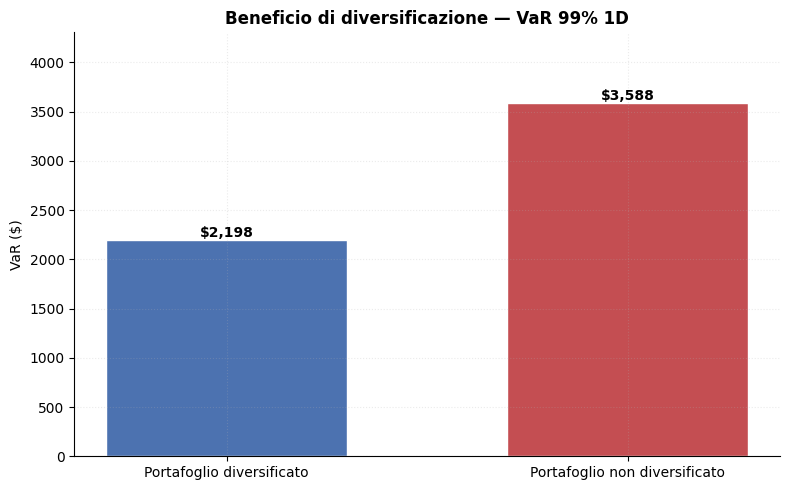

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = summary_div_4d[f"VaR {(1 - ALPHA):.0%} {HORIZON_DAYS}D ($)"]

bars = ax.bar(
    plot_data.index,
    plot_data.values,
    color=["#4c72b0", "#c44e52"],
    edgecolor="white",
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel("VaR ($)")
ax.set_title(
    f"Beneficio di diversificazione — VaR {(1 - ALPHA):.0%} {HORIZON_DAYS}D"
)

ax.set_ylim(0, plot_data.max() * 1.20)

plt.tight_layout()
plt.show()

### PUNTO 4E

la volatilità del portafoglio negli ultimi 3 anni appare costante o mostra dinamiche significative?